In [1]:
!pip install -r requirements.txt

In [2]:
# Increase cell width for better viewing
from IPython.display import display, HTML
display(HTML("<style>.container { width:75% !important; }</style>"))

In [3]:
# Import basic libraries/modules
import numpy as np
import pandas as pd

# Import visual libraries/modules
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

# Scikit-learn
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt

from statsmodels.regression.linear_model import OLS, OLSResults
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import signal

# ARIMA 
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf

# PMDARIMA
import pmdarima as pm

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Matplotlib font color change
COLOR = 'white'
mpl.rcParams['text.color'] = COLOR
mpl.rcParams['axes.labelcolor'] = COLOR
mpl.rcParams['xtick.color'] = COLOR
mpl.rcParams['ytick.color'] = COLOR

from matplotlib import style
style.use('dark_background')

In [5]:
# Import and view Dataset
cyber_ops = pd.read_csv('../Cyber_Threat_Time_Series/cyber-operations-incidents.csv')
cyber_ops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         869 non-null    object
 1   Date          852 non-null    object
 2   Affiliations  724 non-null    object
 3   Description   869 non-null    object
 4   Response      287 non-null    object
 5   Victims       842 non-null    object
 6   Sponsor       828 non-null    object
 7   Type          834 non-null    object
 8   Category      844 non-null    object
 9   Sources_1     866 non-null    object
 10  Sources_2     519 non-null    object
 11  Sources_3     195 non-null    object
dtypes: object(12)
memory usage: 81.6+ KB


In [6]:
# Drop unnecessary columns
cyber_ops.drop(['Title', 'Affiliations', 'Description', 'Response', 'Victims', 'Category', 'Sources_1', 'Sources_2', 'Sources_3'], axis=1, inplace=True)
cyber_ops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     852 non-null    object
 1   Sponsor  828 non-null    object
 2   Type     834 non-null    object
dtypes: object(3)
memory usage: 20.5+ KB


In [7]:
# Shape of the dataset
cyber_ops.shape

(869, 3)

In [8]:
# View null values from dataset
cyber_ops.isnull().sum()

Date       17
Sponsor    41
Type       35
dtype: int64

In [9]:
# Drop rows with missing values
cyber_ops.dropna(inplace=True)
cyber_ops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 785 entries, 0 to 851
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     785 non-null    object
 1   Sponsor  785 non-null    object
 2   Type     785 non-null    object
dtypes: object(3)
memory usage: 24.5+ KB


In [10]:
# Shape of the dataset
cyber_ops.shape

(785, 3)

In [11]:
# View the first 10 rows of the dataset
cyber_ops.head(10)

,Date,Sponsor,Type
0,2023-01-23,Korea (Democratic People's Republic of),Financial Theft
1,2023-04-24,Korea (Democratic People's Republic of),Espionage
2,2023-06-15,China,Espionage
3,2023-03-01,China,Espionage
4,2023-05-04,Korea (Republic of),Espionage
5,2023-07-26,Korea (Democratic People's Republic of),Financial Theft
6,2023-03-30,Korea (Democratic People's Republic of),Espionage
7,2023-05-24,China,Espionage
8,2023-09-11,Iran (Islamic Republic of),Espionage
9,2023-01-26,United States,Data destruction


In [12]:
# View unique Sponsor values
cyber_ops.Sponsor.unique()

array(["Korea (Democratic People's Republic of)", 'China',
       'Korea (Republic of)', 'Iran (Islamic Republic of)',
       'United States', 'Pakistan', 'India', 'Russian Federation',
       'Mexico', 'Australia', 'Vietnam', 'Greece', 'Ukraine',
       'El Salvador', 'Belarus', 'Bahrain', 'Myanmar',
       'United Arab Emirates', 'Ghana', 'Canada', 'Israel', 'Jordan',
       'Palestine, State of', 'Belarus, Russian Federation', 'Spain',
       'Thailand', 'The Philippines', 'South Sudan', 'Saudi Arabia',
       'Poland', 'Japan',
       'United States, Canada, France, Germany, Lithuania, Netherlands, Ukraine, United Kingdom',
       'United States, Bulgaria', 'Syrian Arab Republic',
       'Saudi Arabia, United Arab Emirates', 'Turkey', 'Togo',
       'United States of America', 'Morocco', 'Hong Kong',
       'China, Russian Federation',
       'United States, Australia, Canada, New Zealand, United Kingdom',
       'Egypt', 'Uzbekistan', 'Lebanon', 'United Kingdom', 'Netherlands',
  

In [13]:
# View Value count of Sponsor
cyber_ops.Sponsor.value_counts()

Sponsor
China                                                                                      274
Russian Federation                                                                         175
Iran (Islamic Republic of)                                                                 102
Korea (Democratic People's Republic of)                                                     96
Pakistan                                                                                    15
United States                                                                               14
Vietnam                                                                                     12
India                                                                                       12
Israel                                                                                       7
United Arab Emirates                                                                         7
Saudi Arabia                              

In [14]:
# View unique sum of Sponsor
cyber_ops.Sponsor.nunique()

57

In [15]:
# If a row value matches a string, replace with new string
cyber_ops['Sponsor'] = cyber_ops['Sponsor'].replace('Palestine, State of', 'Palestine (State of)')
cyber_ops['Sponsor'] = cyber_ops['Sponsor'].replace('United States of America', 'United States')

In [16]:
# Split Sponsor column on , and copy row to new row
cyber_ops = cyber_ops.assign(Sponsor=cyber_ops['Sponsor'].str.split(', ')).explode('Sponsor')
cyber_ops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 806 entries, 0 to 851
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     806 non-null    object
 1   Sponsor  806 non-null    object
 2   Type     806 non-null    object
dtypes: object(3)
memory usage: 25.2+ KB


In [17]:
# View unique Sponsor values
cyber_ops.Sponsor.unique()

array(["Korea (Democratic People's Republic of)", 'China',
       'Korea (Republic of)', 'Iran (Islamic Republic of)',
       'United States', 'Pakistan', 'India', 'Russian Federation',
       'Mexico', 'Australia', 'Vietnam', 'Greece', 'Ukraine',
       'El Salvador', 'Belarus', 'Bahrain', 'Myanmar',
       'United Arab Emirates', 'Ghana', 'Canada', 'Israel', 'Jordan',
       'Palestine (State of)', 'Spain', 'Thailand', 'The Philippines',
       'South Sudan', 'Saudi Arabia', 'Poland', 'Japan', 'France',
       'Germany', 'Lithuania', 'Netherlands', 'United Kingdom',
       'Bulgaria', 'Syrian Arab Republic', 'Turkey', 'Togo', 'Morocco',
       'Hong Kong', 'New Zealand', 'Egypt', 'Uzbekistan', 'Lebanon',
       'Ethiopia', 'Panama', 'Indonesia', 'Kazakhstan', 'Uganda',
       'Taiwan'], dtype=object)

In [18]:
# View dataset value count after splitting
cyber_ops['Sponsor'].value_counts()

Sponsor
China                                      276
Russian Federation                         178
Iran (Islamic Republic of)                 102
Korea (Democratic People's Republic of)     96
United States                               24
Pakistan                                    15
India                                       12
Vietnam                                     12
Israel                                      10
United Arab Emirates                         8
Saudi Arabia                                 6
Ukraine                                      5
Belarus                                      5
Mexico                                       4
Australia                                    4
United Kingdom                               4
Palestine (State of)                         4
Korea (Republic of)                          3
Canada                                       3
Spain                                        2
Netherlands                                  2
Franc

In [19]:
# View unique sum of Sponsor
cyber_ops['Sponsor'].nunique()

51

In [20]:
# Export cleaned data set to csv
cyber_ops.to_csv('../Cyber_Threat_Time_Series//CSV_Files/Cleaned_CyberOps.csv', index=False)

In [21]:
# Import cleaned dataset
CyberOps_df = pd.read_csv('../Cyber_Threat_Time_Series//CSV_Files/Cleaned_CyberOps.csv')
CyberOps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     806 non-null    object
 1   Sponsor  806 non-null    object
 2   Type     806 non-null    object
dtypes: object(3)
memory usage: 19.0+ KB


<Axes: xlabel='Type', ylabel='count'>

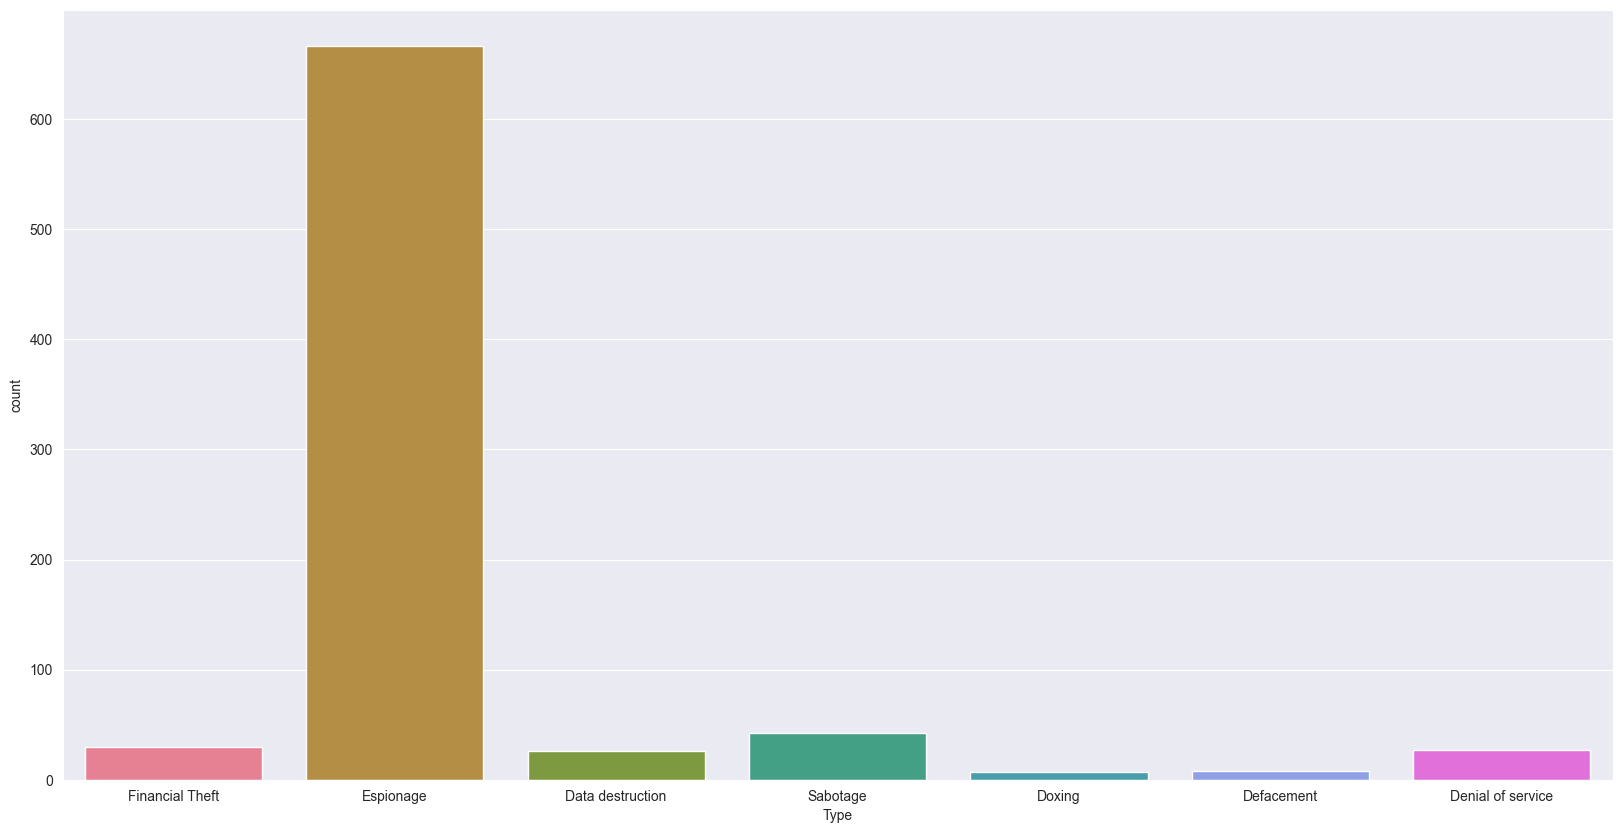

In [22]:
# Visualize the data
sns.set_style('darkgrid')
plt.figure(figsize=(20,10))
sns.countplot(x='Type', data=CyberOps_df, palette='husl')

In [23]:
# Make Date a datetime object and index
CyberOps_df['Date'] = pd.to_datetime(CyberOps_df['Date'])
CyberOps_df.set_index('Date', inplace=True)
CyberOps_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 806 entries, 2023-01-23 to 2005-08-25
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sponsor  806 non-null    object
 1   Type     806 non-null    object
dtypes: object(2)
memory usage: 18.9+ KB


In [24]:
# Dataframe correlating Dates, Sponsor.Type and Category of cyber operation
CyberOps_df_new = CyberOps_df.groupby(['Date', 'Sponsor', 'Type']).size().unstack(fill_value=0)
CyberOps_df_new.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 737 entries, (Timestamp('2005-08-25 00:00:00'), 'China') to (Timestamp('2023-09-27 00:00:00'), 'China')
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Data destruction   737 non-null    int64
 1   Defacement         737 non-null    int64
 2   Denial of service  737 non-null    int64
 3   Doxing             737 non-null    int64
 4   Espionage          737 non-null    int64
 5   Financial Theft    737 non-null    int64
 6   Sabotage           737 non-null    int64
dtypes: int64(7)
memory usage: 47.9+ KB


In [25]:
# View Dataframe
CyberOps_df_new

Type                           Data destruction  Defacement  \
Date       Sponsor                                            
2005-08-25 China                              0           0   
2006-07-11 China                              0           0   
2006-08-17 China                              0           0   
2006-12-04 China                              0           0   
2007-01-12 China                              0           0   
...                                         ...         ...   
2023-09-19 China                              0           0   
2023-09-21 China                              0           0   
           Russian Federation                 0           0   
2023-09-22 China                              0           0   
2023-09-27 China                              0           0   

Type                           Denial of service  Doxing  Espionage  \
Date       Sponsor                                                    
2005-08-25 China                               0       0          1   
2006-07-11 China                               0       0          1   
2006-08-17 China                               0       0          1   
2006-12-04 China                               0       0          1   
2007-01-12 China                               0       0          1   
...                                          ...     ...        ...   
2023-09-19 China                               0       0          1   
2023-09-21 China                               0       0          1   
           Russian Federation                  0       0          1   
2023-09-22 China                               0       0          1   
2023-09-27 China                               0       0          1   

Type                           Financial Theft  Sabotage  
Date       Sponsor                                        
2005-08-25 China                             0         0  
2006-07-11 China                             0         0  
2006-08-17 China                             0         0  
2006-12-04 China                             0         0  
2007-01-12 China                             0         0  
...                                        ...       ...  
2023-09-19 China                             0         0  
2023-09-21 China                             0         0  
           Russian Federation                0         0  
2023-09-22 China                             0         0  
2023-09-27 China                             0         0  

[737 rows x 7 columns]

In [26]:
# Export CSV
CyberOps_df_new.to_csv('../Cyber_Threat_Time_Series/CSV_Files/CyberOps_df_new.csv')

In [27]:
CyberOps_df_new.head(20)

,Type,Data destruction,Defacement,Denial of service,Doxing,Espionage,Financial Theft,Sabotage
Date,Sponsor,,,,,,,
2005-08-25,China,0,0,0,0,1,0,0
2006-07-11,China,0,0,0,0,1,0,0
2006-08-17,China,0,0,0,0,1,0,0
2006-12-04,China,0,0,0,0,1,0,0
2007-01-12,China,0,0,0,0,1,0,0
2007-05-16,Russian Federation,0,0,1,0,0,0,0
2007-06-22,China,0,0,0,0,1,0,0
2007-08-27,China,0,0,0,0,1,0,0
2007-09-09,China,0,0,0,0,1,0,0


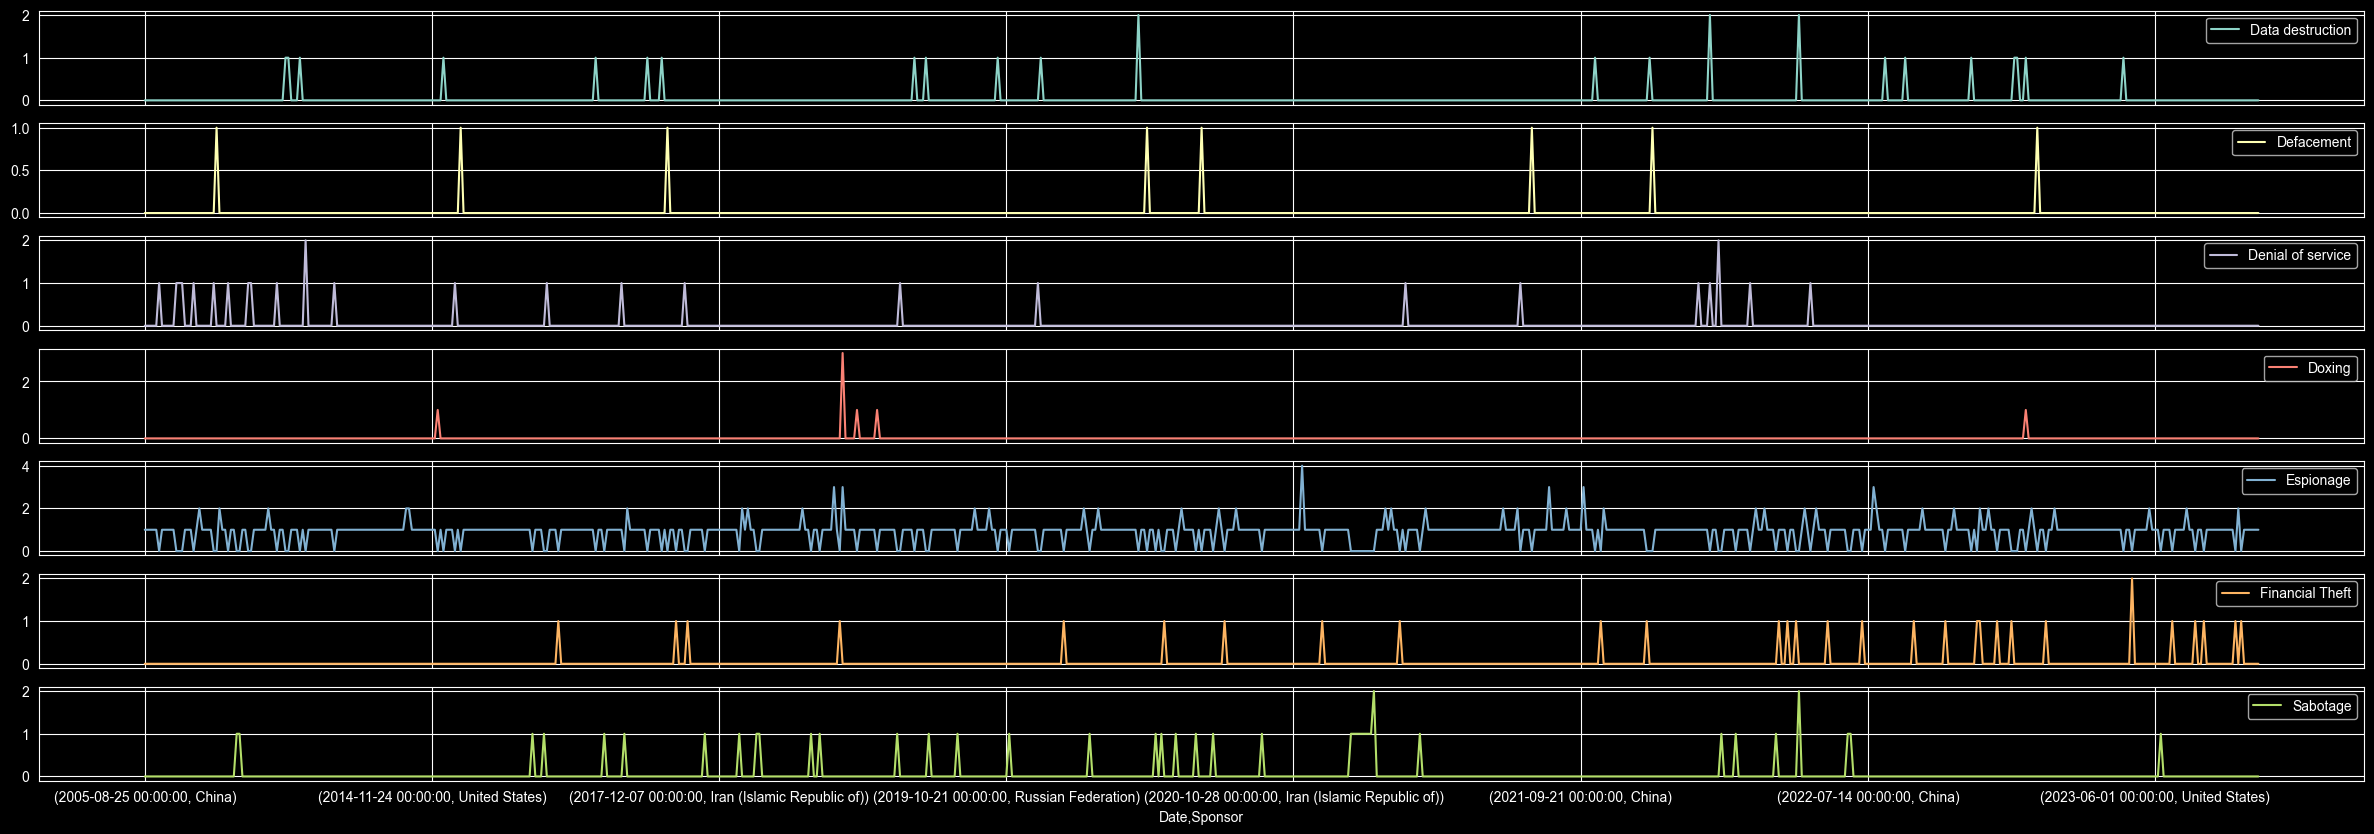

In [28]:
# Multivariate time series plot of the data
plt.style.use('dark_background')
CyberOps_df_new[['Data destruction', 'Defacement', 'Denial of service', 'Doxing', 'Espionage', 'Financial Theft', 'Sabotage']].plot(subplots=True, figsize=(30, 10))
plt.show()

In [29]:
# Description of the data
CyberOps_df_new.describe()

Type,Data destruction,Defacement,Denial of service,Doxing,Espionage,Financial Theft,Sabotage
count,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000
mean,0.035278,0.010855,0.036635,0.009498,0.903664,0.040706,0.056988
std,0.205504,0.103690,0.201930,0.132562,0.494755,0.204497,0.243409
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2.000000,1.000000,2.000000,3.000000,4.000000,2.000000,2.000000


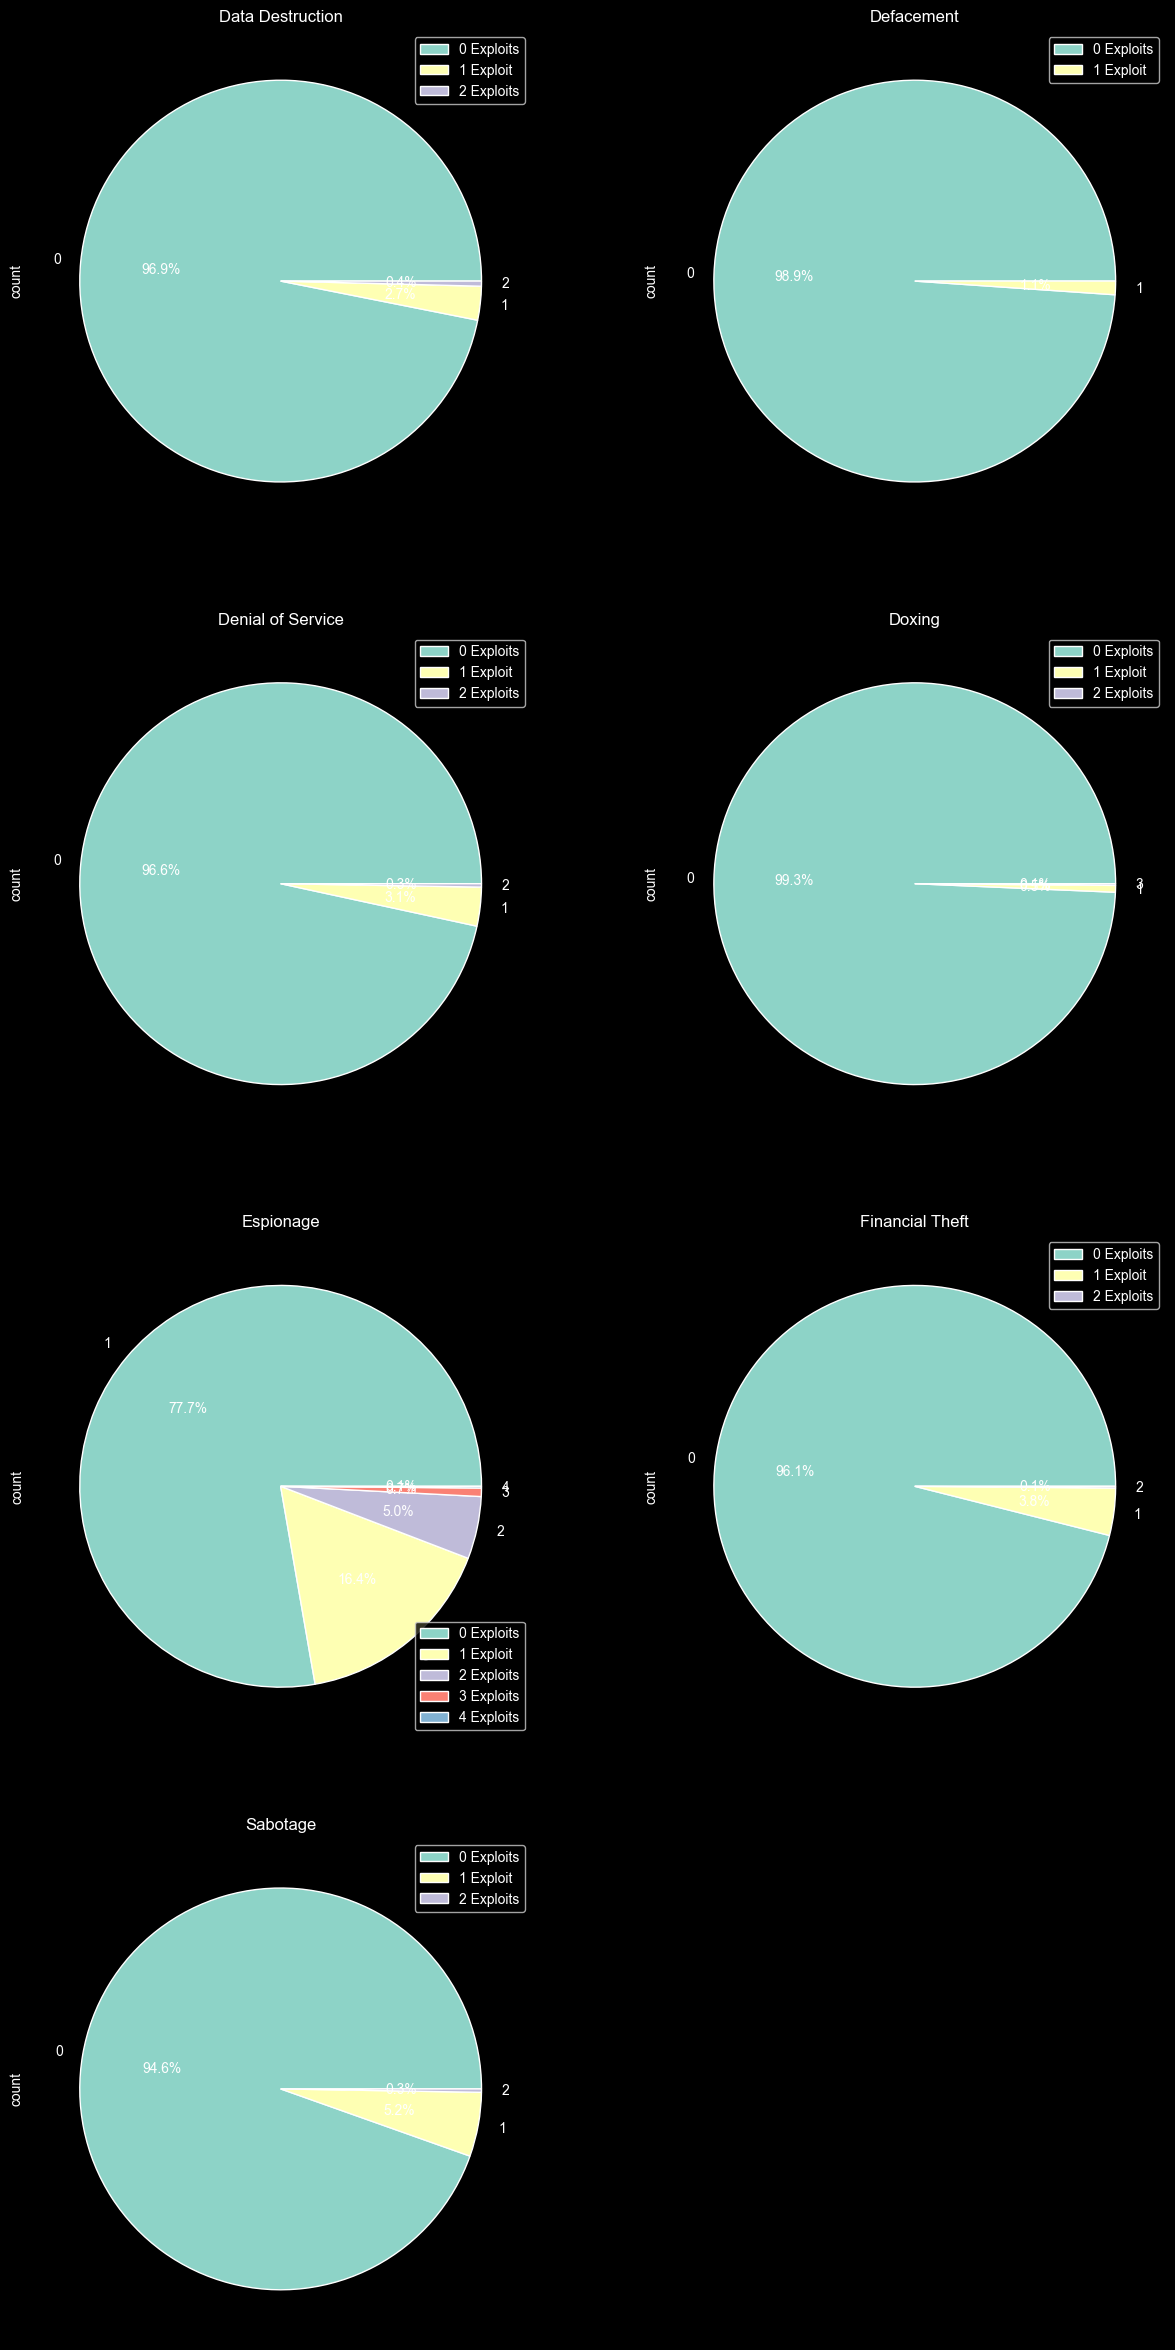

In [30]:
plt.style.use('dark_background')

plt.subplot(4, 2, 1)
CyberOps_df_new['Data destruction'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Data Destruction')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 2)
CyberOps_df_new['Defacement'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Defacement')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 3)
CyberOps_df_new['Denial of service'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Denial of Service')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 4)
CyberOps_df_new['Doxing'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Doxing')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 5)
CyberOps_df_new['Espionage'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Espionage')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 6)
CyberOps_df_new['Financial Theft'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Financial Theft')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.subplot(4, 2, 7)
CyberOps_df_new['Sabotage'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(15, 30), title='Sabotage')
plt.legend(labels=['0 Exploits', '1 Exploit', '2 Exploits', '3 Exploits', '4 Exploits', '5 Exploits'])

plt.show()

In [31]:
# View Dataframe
CyberOps_df_new

Type                           Data destruction  Defacement  \
Date       Sponsor                                            
2005-08-25 China                              0           0   
2006-07-11 China                              0           0   
2006-08-17 China                              0           0   
2006-12-04 China                              0           0   
2007-01-12 China                              0           0   
...                                         ...         ...   
2023-09-19 China                              0           0   
2023-09-21 China                              0           0   
           Russian Federation                 0           0   
2023-09-22 China                              0           0   
2023-09-27 China                              0           0   

Type                           Denial of service  Doxing  Espionage  \
Date       Sponsor                                                    
2005-08-25 China                               0       0          1   
2006-07-11 China                               0       0          1   
2006-08-17 China                               0       0          1   
2006-12-04 China                               0       0          1   
2007-01-12 China                               0       0          1   
...                                          ...     ...        ...   
2023-09-19 China                               0       0          1   
2023-09-21 China                               0       0          1   
           Russian Federation                  0       0          1   
2023-09-22 China                               0       0          1   
2023-09-27 China                               0       0          1   

Type                           Financial Theft  Sabotage  
Date       Sponsor                                        
2005-08-25 China                             0         0  
2006-07-11 China                             0         0  
2006-08-17 China                             0         0  
2006-12-04 China                             0         0  
2007-01-12 China                             0         0  
...                                        ...       ...  
2023-09-19 China                             0         0  
2023-09-21 China                             0         0  
           Russian Federation                0         0  
2023-09-22 China                             0         0  
2023-09-27 China                             0         0  

[737 rows x 7 columns]

In [32]:
# List top 10 sponsors for Data detsruction
CyberOps_df_new['Data destruction'].nlargest(10)

Date        Sponsor                                
2020-04-06  Australia                                  2
2022-02-23  Russian Federation                         2
2022-04-27  Russian Federation                         2
2012-05-28  Israel                                     1
            United States                              1
2012-08-16  Iran (Islamic Republic of)                 1
2014-12-12  Iran (Islamic Republic of)                 1
2016-12-13  Russian Federation                         1
2017-06-14  Korea (Democratic People's Republic of)    1
2017-07-01  Russian Federation                         1
Name: Data destruction, dtype: int64

In [33]:
# List top 10 sponsors for Defacement
CyberOps_df_new['Defacement'].nlargest(10)

Date        Sponsor                   
2010-01-12  Iran (Islamic Republic of)    1
2015-04-09  Russian Federation            1
2017-07-16  United Arab Emirates          1
2020-04-23  Russian Federation            1
2020-07-29  Russian Federation            1
2021-07-09  Russian Federation            1
2022-01-16  Belarus                       1
2023-02-23  Russian Federation            1
2005-08-25  China                         0
2006-07-11  China                         0
Name: Defacement, dtype: int64

In [34]:
# List top 10 sponsors for Denial of service
CyberOps_df_new['Denial of service'].nlargest(10)

Date        Sponsor                                
2012-09-18  Iran (Islamic Republic of)                 2
2022-02-28  Ukraine                                    2
2007-05-16  Russian Federation                         1
2007-10-04  Israel                                     1
2007-10-23  Taiwan                                     1
            United States                              1
2008-08-13  Russian Federation                         1
2009-07-08  Korea (Democratic People's Republic of)    1
2010-03-30  Vietnam                                    1
2011-04-09  Korea (Democratic People's Republic of)    1
Name: Denial of service, dtype: int64

In [35]:
# List top 10 sponsors for Doxing
CyberOps_df_new['Doxing'].nlargest(10)

Date        Sponsor                                
2018-10-04  Russian Federation                         3
2014-12-03  Korea (Democratic People's Republic of)    1
2018-11-29  Russian Federation                         1
2018-12-28  Korea (Democratic People's Republic of)    1
2023-02-08  Russian Federation                         1
2005-08-25  China                                      0
2006-07-11  China                                      0
2006-08-17  China                                      0
2006-12-04  China                                      0
2007-01-12  China                                      0
Name: Doxing, dtype: int64

In [36]:
# List top 10 sponsors for Espionage
CyberOps_df_new['Espionage'].nlargest(10)

Date        Sponsor                                
2020-11-13  Korea (Democratic People's Republic of)    4
2018-09-06  Korea (Democratic People's Republic of)    3
2018-10-04  Russian Federation                         3
2021-08-03  China                                      3
2021-09-28  China                                      3
2022-07-18  China                                      3
2008-11-19  China                                      2
2010-01-14  China                                      2
2011-11-09  China                                      2
2014-09-10  China                                      2
Name: Espionage, dtype: int64

In [37]:
# List top 10 sponsors for Financial Theft
CyberOps_df_new['Financial Theft'].nlargest(10)

Date        Sponsor                                
2023-05-08  Iran (Islamic Republic of)                 2
2016-05-26  Korea (Democratic People's Republic of)    1
2017-09-11  Korea (Democratic People's Republic of)    1
2017-10-07  Korea (Democratic People's Republic of)    1
2018-10-03  Korea (Democratic People's Republic of)    1
2020-01-08  Korea (Democratic People's Republic of)    1
2020-05-12  Korea (Democratic People's Republic of)    1
2020-08-26  Korea (Democratic People's Republic of)    1
2020-11-30  Vietnam                                    1
2021-02-17  Korea (Democratic People's Republic of)    1
Name: Financial Theft, dtype: int64

In [38]:
# Add a Total Exploits column
CyberOps_df_new['Total Exploits'] = CyberOps_df_new.sum(axis=1)

In [39]:
CyberOps_df_new.head(20)

,Type,Data destruction,Defacement,Denial of service,Doxing,Espionage,Financial Theft,Sabotage,Total Exploits
Date,Sponsor,,,,,,,,
2005-08-25,China,0,0,0,0,1,0,0,1
2006-07-11,China,0,0,0,0,1,0,0,1
2006-08-17,China,0,0,0,0,1,0,0,1
2006-12-04,China,0,0,0,0,1,0,0,1
2007-01-12,China,0,0,0,0,1,0,0,1
2007-05-16,Russian Federation,0,0,1,0,0,0,0,1
2007-06-22,China,0,0,0,0,1,0,0,1
2007-08-27,China,0,0,0,0,1,0,0,1
2007-09-09,China,0,0,0,0,1,0,0,1


In [40]:
# Sponsor list from unique values in Sponsor column
sponsor_list = CyberOps_df['Sponsor'].unique().tolist()
sponsor_list

["Korea (Democratic People's Republic of)",
 'China',
 'Korea (Republic of)',
 'Iran (Islamic Republic of)',
 'United States',
 'Pakistan',
 'India',
 'Russian Federation',
 'Mexico',
 'Australia',
 'Vietnam',
 'Greece',
 'Ukraine',
 'El Salvador',
 'Belarus',
 'Bahrain',
 'Myanmar',
 'United Arab Emirates',
 'Ghana',
 'Canada',
 'Israel',
 'Jordan',
 'Palestine (State of)',
 'Spain',
 'Thailand',
 'The Philippines',
 'South Sudan',
 'Saudi Arabia',
 'Poland',
 'Japan',
 'France',
 'Germany',
 'Lithuania',
 'Netherlands',
 'United Kingdom',
 'Bulgaria',
 'Syrian Arab Republic',
 'Turkey',
 'Togo',
 'Morocco',
 'Hong Kong',
 'New Zealand',
 'Egypt',
 'Uzbekistan',
 'Lebanon',
 'Ethiopia',
 'Panama',
 'Indonesia',
 'Kazakhstan',
 'Uganda',
 'Taiwan']

In [41]:
# Function that takes user input for start and end date
def total_exploit():
    start = input('Enter a start date in YYYY-MM-DD format: ')
    end = input('Enter an end date in YYYY-MM-DD format: ')
    return CyberOps_df_new.loc[start:end].groupby('Sponsor').sum().sort_values(by='Total Exploits', ascending=False)

In [42]:
total_exploit()

Type,Data destruction,Defacement,Denial of service,Doxing,Espionage,Financial Theft,Sabotage,Total Exploits
Sponsor,,,,,,,,
China,1,0,2,0,270,1,2,276
Russian Federation,12,5,8,5,134,0,14,178
Iran (Islamic Republic of),5,1,3,0,84,6,3,102
Korea (Democratic People's Republic of),1,0,4,2,67,22,0,96
United States,4,0,3,0,8,0,9,24
Pakistan,0,0,0,0,15,0,0,15
Vietnam,0,0,1,0,10,1,0,12
India,0,0,0,0,11,0,1,12
Israel,1,0,1,0,6,0,2,10


In [43]:
# Make a dataframe with dates and Total Exploits
CyberOps_df_TS = CyberOps_df_new[['Total Exploits']]

# Return top 5 dates with the most exploits
CyberOps_df_TS.nlargest(5, 'Total Exploits')

,Type,Total Exploits
Date,Sponsor,
2018-10-04,Russian Federation,6
2020-11-13,Korea (Democratic People's Republic of),4
2022-04-27,Russian Federation,4
2018-09-06,Korea (Democratic People's Republic of),3
2021-08-03,China,3


In [44]:
# Remove Sponsor index from CyberOps_df_new2
CyberOps_df_TS.reset_index(inplace=True)

# Set date as index
CyberOps_df_TS.set_index('Date', inplace=True)

# Drop Sponsor coulmn from CyberOps_df_new2
CyberOps_df_TS.drop('Sponsor', axis=1, inplace=True)


In [45]:
CyberOps_df_TS

Type,Total Exploits
Date,
2005-08-25,1
2006-07-11,1
2006-08-17,1
2006-12-04,1
2007-01-12,1
...,...
2023-09-19,1
2023-09-21,1
2023-09-21,1


In [46]:
# View the shape of the CyberOps_df_TS
CyberOps_df_TS.shape

(737, 1)

In [47]:
# Return top 5 dates with the most exploits
CyberOps_df_TS.nlargest(5, 'Total Exploits')

Type,Total Exploits
Date,
2018-10-04,6
2020-11-13,4
2022-04-27,4
2018-09-06,3
2021-08-03,3


PART 2 FOR TIME SERIES USING CyberOps_df_TS

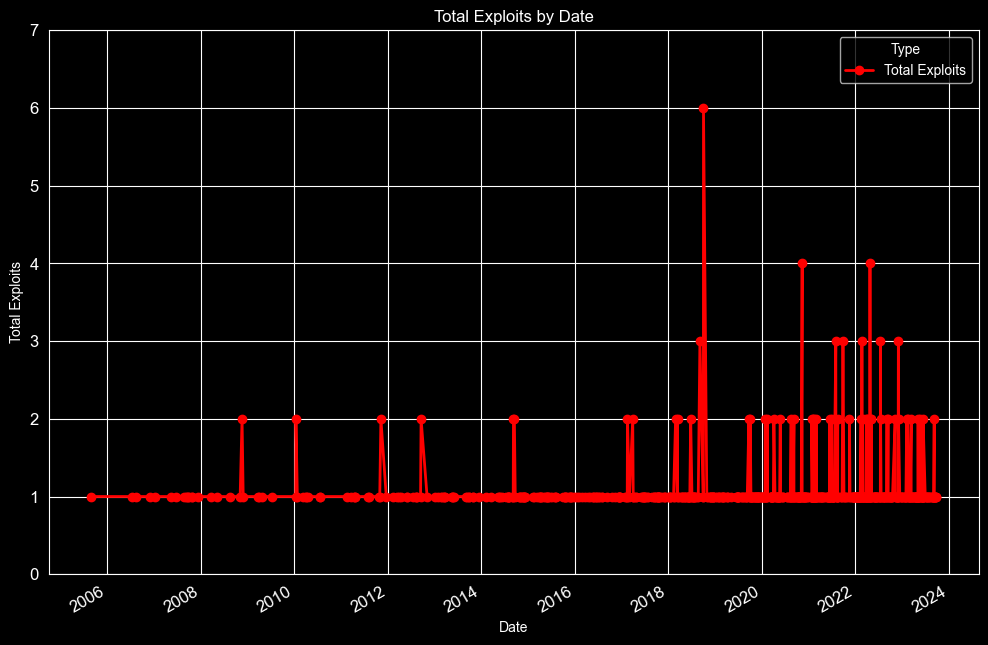

In [48]:
# Generate a Line Graph of CyberOps_df_TS for Time Sereis Realization
plt.style.use('dark_background')
CyberOps_df_TS.plot(figsize=(12, 8), linewidth=2, fontsize=12, color='red', marker='o')
plt.title('Total Exploits by Date')
plt.xlabel('Date')
plt.ylabel('Total Exploits')
plt.yticks(np.arange(0, 8, 1))
plt.grid(True)
plt.show()

In [49]:
CyberOps_df_TS.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 737 entries, 2005-08-25 to 2023-09-27
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Total Exploits  737 non-null    int64
dtypes: int64(1)
memory usage: 11.5 KB


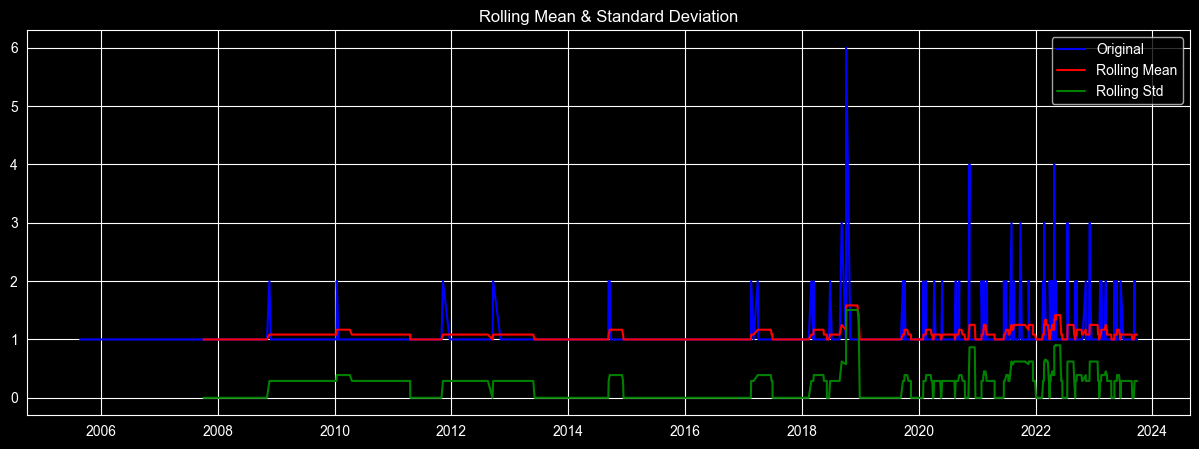

Results of Dickey-Fuller Test:
Test Statistic                 -14.370000
p-value                          0.000000
#Lags Used                       2.000000
Number of Observations Used    734.000000
Critical Value (1%)             -3.439290
Critical Value (5%)             -2.865486
Critical Value (10%)            -2.568871
dtype: float64
p-value is 0.0 . Reject null hypothesis, the series is likely stationary.


In [50]:
def test_stationarity(timeseries):
    #Determine Rolling Statistics
    rolmean = timeseries['Total Exploits'].rolling(window=12).mean()
    rolstd = timeseries['Total Exploits'].rolling(window=12).std()
    
    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    plt.plot(timeseries['Total Exploits'], color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='green', label = 'Rolling Std')
    plt.title('Rolling Mean & Standard Deviation')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries['Total Exploits'].dropna())
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    dfoutput = dfoutput.round(2)
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    # Validate stationary status
    if dftest[1] <= 0.05:
        dftest = list(dftest)
        dftest[1] = round(dftest[1], 2)
        dftest = tuple(dftest)
        print('p-value is', dftest[1],'. Reject null hypothesis, the series is likely stationary.')
    else:
        print('p-value is', dftest[1],'. Fail to reject null hypothesis, the series is likely non-stationary.')

test_stationarity(CyberOps_df_TS)

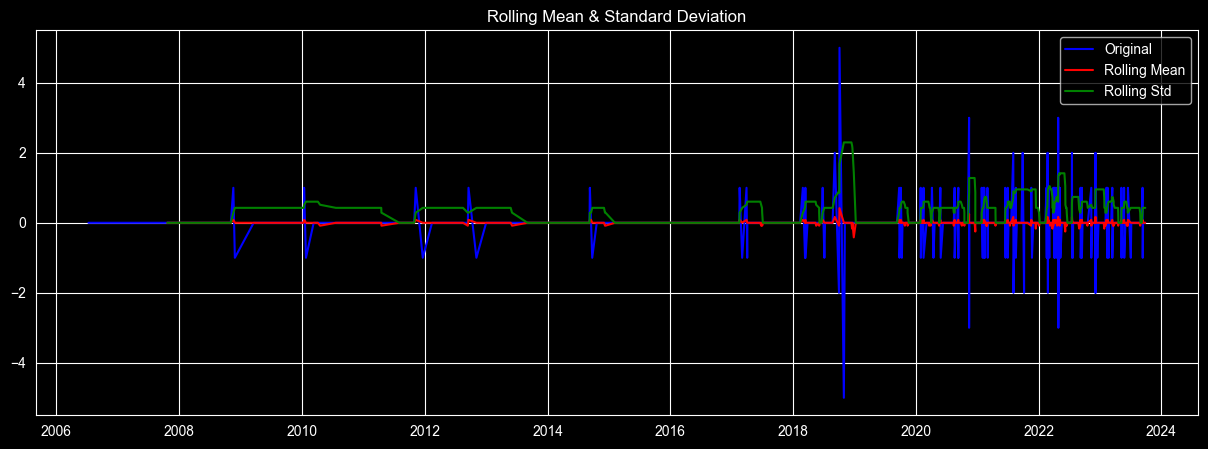

Results of Dickey-Fuller Test:
Test Statistic                 -12.370000
p-value                          0.000000
#Lags Used                      14.000000
Number of Observations Used    721.000000
Critical Value (1%)             -3.439452
Critical Value (5%)             -2.865557
Critical Value (10%)            -2.568909
dtype: float64
p-value is 0.0 . Reject null hypothesis, the series is likely stationary.


In [51]:
def make_stationary(timeseries):
    timeseries['Total Exploits_diff'] = timeseries['Total Exploits'] - timeseries['Total Exploits'].shift(1)
    timeseries.dropna(inplace=True)
    
    #Determine Rolling Statistics
    rolmean = timeseries['Total Exploits_diff'].rolling(window=12).mean()
    rolstd = timeseries['Total Exploits_diff'].rolling(window=12).std()
    
    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    plt.plot(timeseries['Total Exploits_diff'], color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='green', label = 'Rolling Std')
    plt.title('Rolling Mean & Standard Deviation')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries['Total Exploits_diff'].dropna())
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    dfoutput = dfoutput.round(2)
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    # Validate stationary status
    if dftest[1] <= 0.05:
        dftest = list(dftest)
        dftest[1] = round(dftest[1], 2)
        dftest = tuple(dftest)
        print('p-value is', dftest[1],'. Reject null hypothesis, the series is likely stationary.')
    else:
        print('p-value is', dftest[1],'. Fail to reject null hypothesis, the series is likely non-stationary.')

make_stationary(CyberOps_df_TS)

In [52]:
# View DataFrame
CyberOps_df_TS

Type,Total Exploits,Total Exploits_diff
Date,,
2006-07-11,1,0.0
2006-08-17,1,0.0
2006-12-04,1,0.0
2007-01-12,1,0.0
2007-05-16,1,0.0
...,...,...
2023-09-19,1,0.0
2023-09-21,1,0.0
2023-09-21,1,0.0


In [53]:
# Split the data into 80% training, 20% testing
X_train = CyberOps_df_TS[:int(0.8*(len(CyberOps_df_TS)))]
X_test = CyberOps_df_TS[int(0.8*(len(CyberOps_df_TS))):]

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)

X_train shape:  (588, 2)
X_test shape:  (148, 2)


In [54]:
# Export the data to a csv file
CyberOps_df_TS.to_csv('../Cyber_Threat_Time_Series/CSV_Files/CyberOps_df_TS.csv')

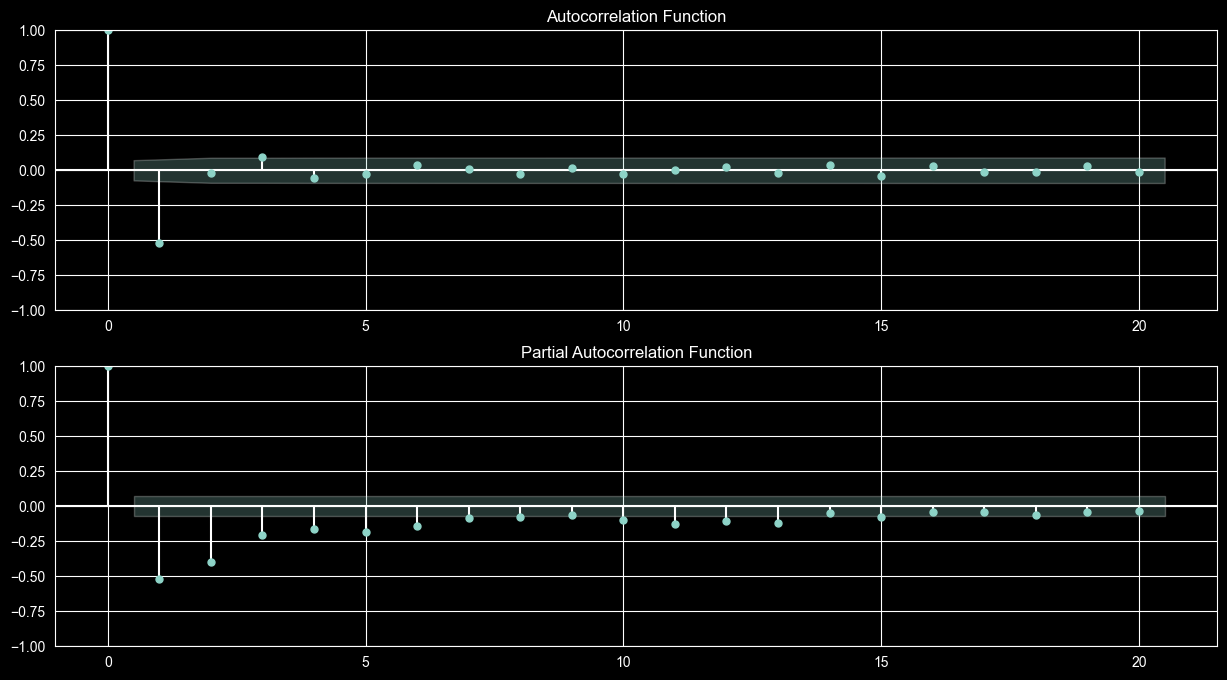

In [55]:
# Auto Correlation Function (ACF) and Partial Auto Correlation Function (PACF) plots after differencing
fig, ax =  plt.subplots(2, 1, figsize=(15, 8))
plot_acf(CyberOps_df_TS['Total Exploits_diff'].dropna(), lags=20, ax=ax[0])
ax[0].set_title('Autocorrelation Function')
plot_pacf(CyberOps_df_TS['Total Exploits_diff'].dropna(), lags=20, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function')
plt.show()

In [56]:
# Show the data
CyberOps_df_TS

Type,Total Exploits,Total Exploits_diff
Date,,
2006-07-11,1,0.0
2006-08-17,1,0.0
2006-12-04,1,0.0
2007-01-12,1,0.0
2007-05-16,1,0.0
...,...,...
2023-09-19,1,0.0
2023-09-21,1,0.0
2023-09-21,1,0.0


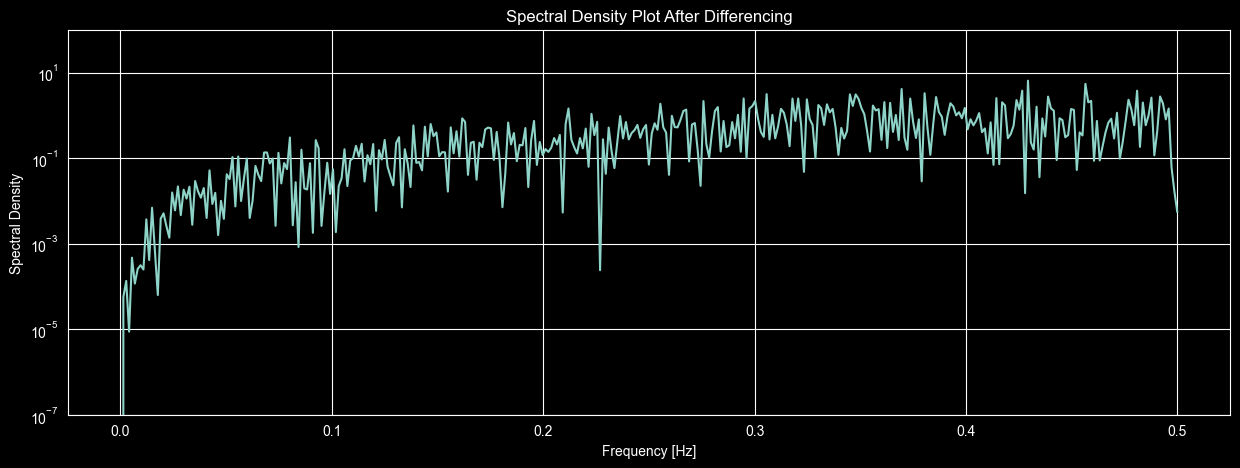

Min Hz:  0.0
Max Hz:  0.5


array([0.        , 0.0013587 , 0.00271739, 0.00407609, 0.00543478,
       0.00679348, 0.00815217, 0.00951087, 0.01086957, 0.01222826,
       0.01358696, 0.01494565, 0.01630435, 0.01766304, 0.01902174,
       0.02038043, 0.02173913, 0.02309783, 0.02445652, 0.02581522,
       0.02717391, 0.02853261, 0.0298913 , 0.03125   , 0.0326087 ,
       0.03396739, 0.03532609, 0.03668478, 0.03804348, 0.03940217,
       0.04076087, 0.04211957, 0.04347826, 0.04483696, 0.04619565,
       0.04755435, 0.04891304, 0.05027174, 0.05163043, 0.05298913,
       0.05434783, 0.05570652, 0.05706522, 0.05842391, 0.05978261,
       0.0611413 , 0.0625    , 0.0638587 , 0.06521739, 0.06657609,
       0.06793478, 0.06929348, 0.07065217, 0.07201087, 0.07336957,
       0.07472826, 0.07608696, 0.07744565, 0.07880435, 0.08016304,
       0.08152174, 0.08288043, 0.08423913, 0.08559783, 0.08695652,
       0.08831522, 0.08967391, 0.09103261, 0.0923913 , 0.09375   ,
       0.0951087 , 0.09646739, 0.09782609, 0.09918478, 0.10054

In [57]:
# Spectral Density Plot after differencing
f, Pxx_den = signal.periodogram(CyberOps_df_TS['Total Exploits_diff'])
plt.figure(figsize=(15,5))
plt.semilogy(f, Pxx_den)
plt.ylim([1e-7, 1e2])
plt.title('Spectral Density Plot After Differencing')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Spectral Density')
plt.show()

# Print the min and max Hz
print('Min Hz: ', f.min())
print('Max Hz: ', f.max())

def freq(timeseries):
    f, Pxx_den = signal.periodogram(timeseries)
    return f

freq(CyberOps_df_TS['Total Exploits_diff'])

In [58]:
# Three periods for decomposition based on the dataset CyberOps_df_TS. 12, 36, 60 months are listed under perio#_M.
period1_M = 12
period2_M = 36
period3_M = 60

p-value is  0.0 . Reject null hypothesis, the series is likely stationary.


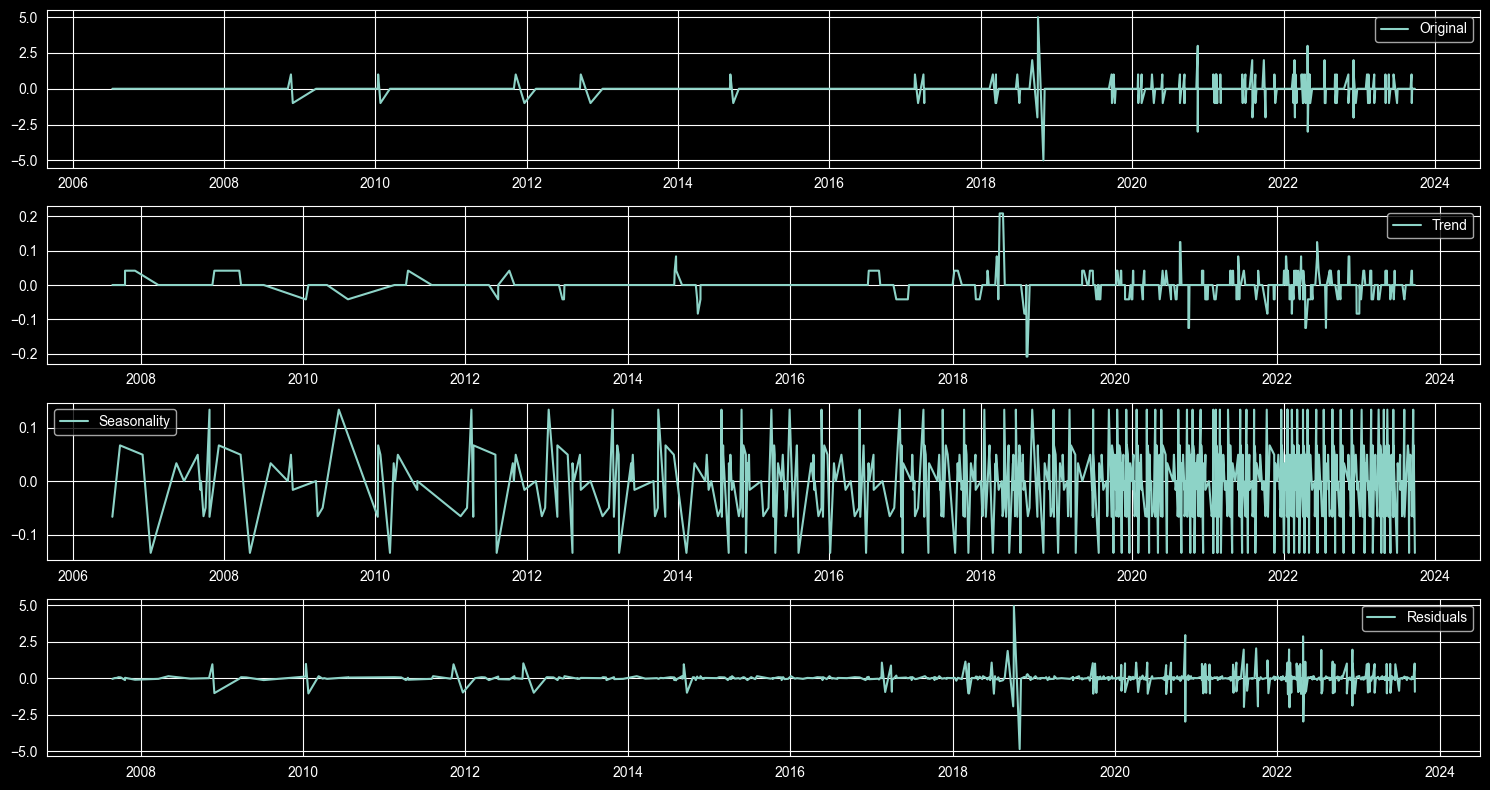

In [59]:
# Decompose the time series into trend, seasonal, and residual components after differencing
decomposition_diff1 = seasonal_decompose(CyberOps_df_TS['Total Exploits_diff'], model='additive', period=period1_M)
decomposition_diff1.trend.dropna(inplace=True)
if adfuller(decomposition_diff1.trend)[1] <= 0.05:
    print('p-value is ', round(adfuller(decomposition_diff1.trend)[1], 2), '. Reject null hypothesis, the series is likely stationary.')
else:
    print('p-value is ', round(adfuller(decomposition_diff1.trend)[1], 2), '. Fail to reject null hypothesis, the series is likely non-stationary.')

# Plot the trend, seasonality, and residual components after differencing
plt.figure(figsize=(15, 8))
plt.subplot(411)
plt.plot(CyberOps_df_TS['Total Exploits_diff'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition_diff1.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition_diff1.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition_diff1.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

p-value is  0.0 . Reject null hypothesis, the series is likely stationary.


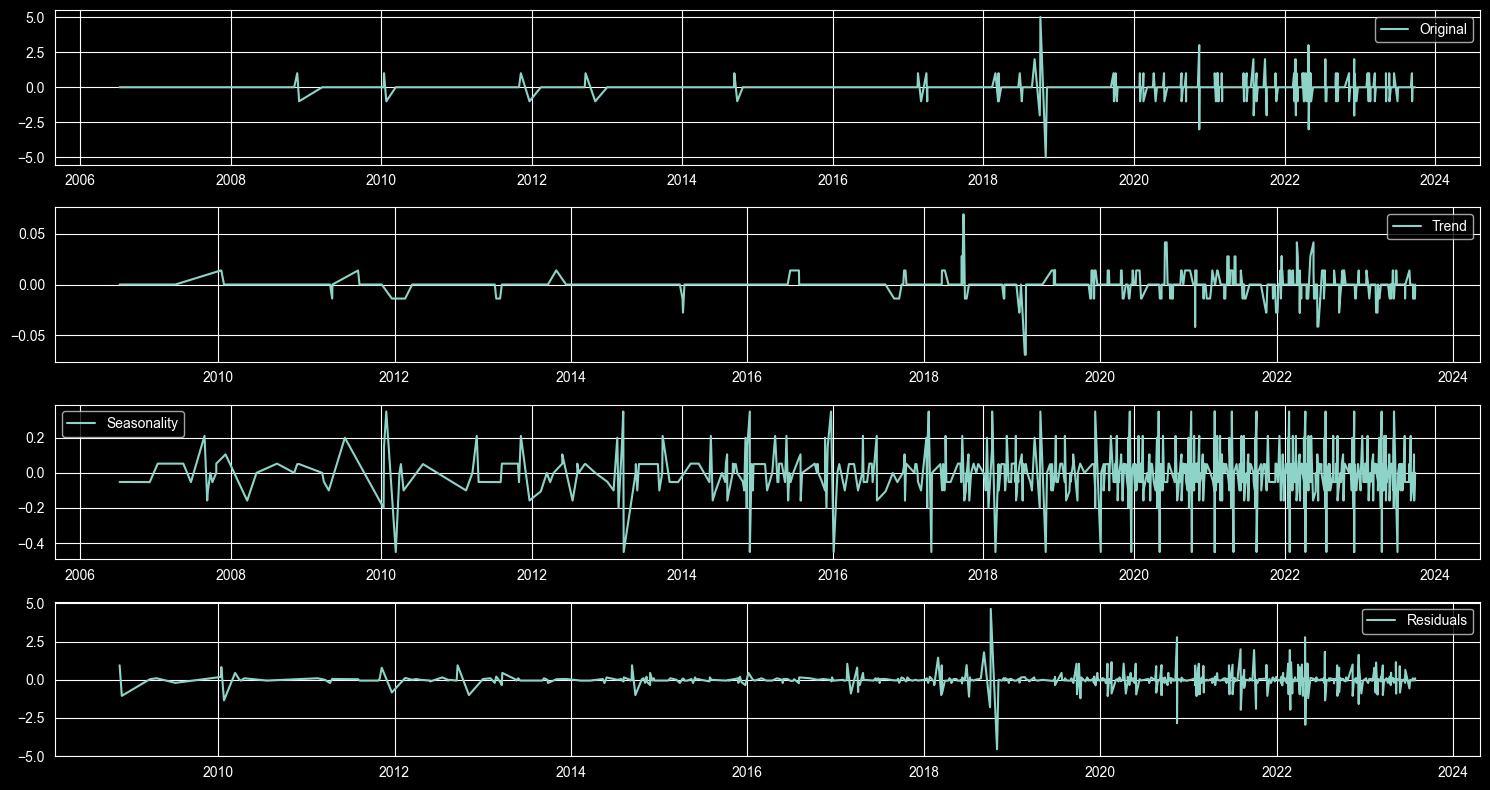

In [60]:
# Decompose the time series into trend, seasonal, and residual components after differencing
decomposition_diff2 = seasonal_decompose(CyberOps_df_TS['Total Exploits_diff'], model='additive', period=period2_M)
decomposition_diff2.trend.dropna(inplace=True)
if adfuller(decomposition_diff2.trend)[1] <= 0.05:
    print('p-value is ', round(adfuller(decomposition_diff2.trend)[1], 2), '. Reject null hypothesis, the series is likely stationary.')
else:
    print('p-value is ', round(adfuller(decomposition_diff2.trend)[1], 2), '. Fail to reject null hypothesis, the series is likely non-stationary.')

# Plot the trend, seasonality, and residual components after differencing
plt.figure(figsize=(15, 8))
plt.subplot(411)
plt.plot(CyberOps_df_TS['Total Exploits_diff'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition_diff2.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition_diff2.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition_diff2.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

p-value is  0.0 . Reject null hypothesis, the series is likely stationary.


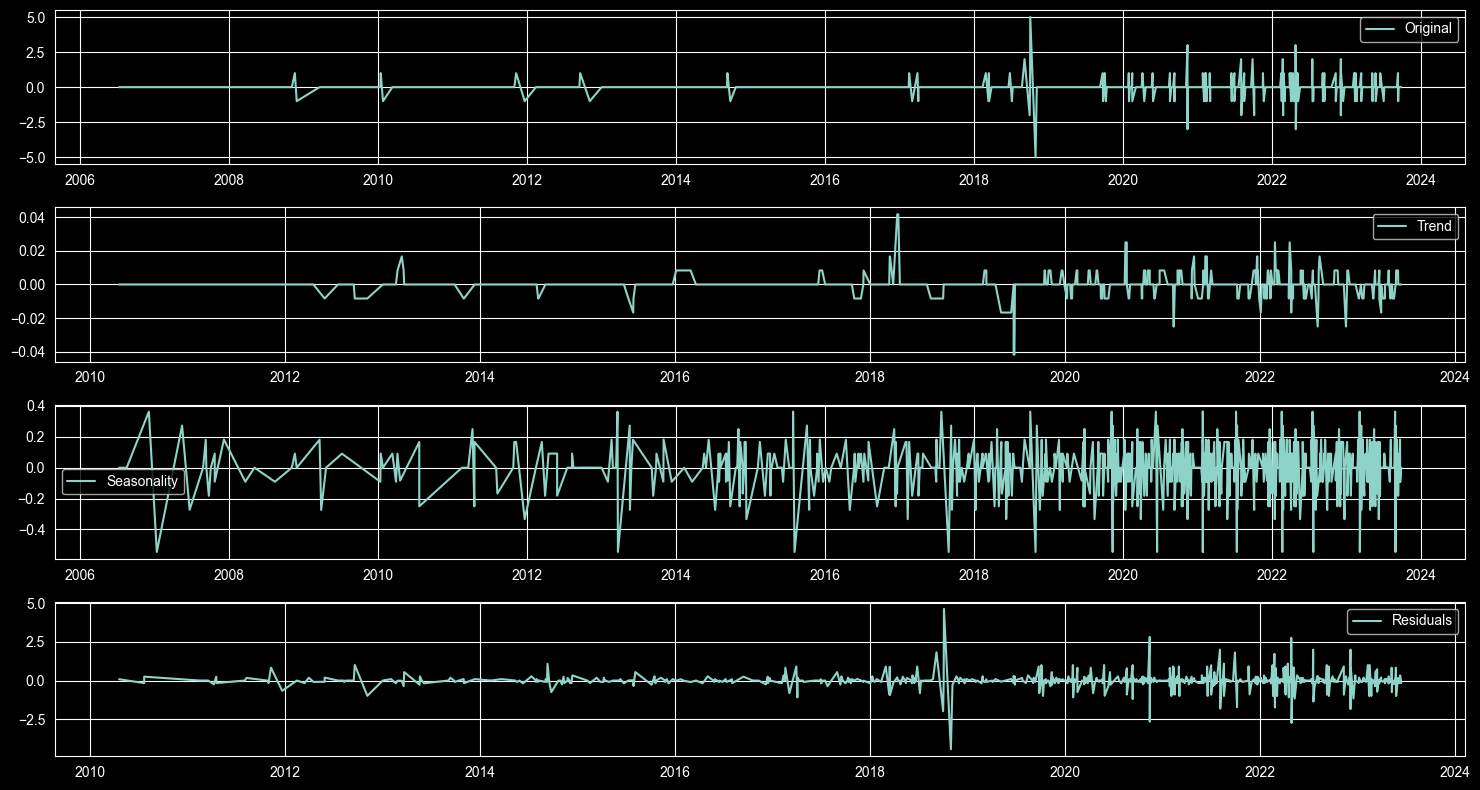

In [61]:
# Decompose the time series into trend, seasonal, and residual components after differencing
decomposition_diff3 = seasonal_decompose(CyberOps_df_TS['Total Exploits_diff'], model='additive', period=period3_M)
decomposition_diff3.trend.dropna(inplace=True)
if adfuller(decomposition_diff3.trend)[1] <= 0.05:
    print('p-value is ', round(adfuller(decomposition_diff3.trend)[1], 2), '. Reject null hypothesis, the series is likely stationary.')
else:
    print('p-value is ', round(adfuller(decomposition_diff3.trend)[1], 2), '. Fail to reject null hypothesis, the series is likely non-stationary.')

# Plot the trend, seasonality, and residual components after differencing
plt.figure(figsize=(15, 8))
plt.subplot(411)
plt.plot(CyberOps_df_TS['Total Exploits_diff'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition_diff3.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition_diff3.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition_diff3.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Make output not exceed
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 1000)

In [62]:
# Function to find the best period for decomposition
def best_period(timeseries):
    decomposition_diff1 = seasonal_decompose(timeseries, model='additive', period=period1_M)
    decomposition_diff1.trend.dropna(inplace=True)
    decomposition_diff2 = seasonal_decompose(timeseries, model='additive', period=period2_M)
    decomposition_diff2.trend.dropna(inplace=True)
    decomposition_diff3 = seasonal_decompose(timeseries, model='additive', period=period3_M)
    decomposition_diff3.trend.dropna(inplace=True)
    if adfuller(decomposition_diff1.trend)[1] <= adfuller(decomposition_diff2.trend)[1] and adfuller(decomposition_diff1.trend)[1] <= adfuller(decomposition_diff3.trend)[1]:
        return print('The best period for decomposition is', period1_M)
    elif adfuller(decomposition_diff2.trend)[1] <= adfuller(decomposition_diff1.trend)[1] and adfuller(decomposition_diff2.trend)[1] <= adfuller(decomposition_diff3.trend)[1]:
        return print('The best period for decomposition is', period2_M)
    else:
        return print('The best period for decomposition is', period3_M)

best_period(CyberOps_df_TS['Total Exploits_diff'])

The best period for decomposition is 12


In [63]:
# Auto-ARIMA model for CyberOps_df_TS after differencing
stepwise_fit_diff = auto_arima(CyberOps_df_TS['Total Exploits_diff'].dropna(), trace=True, suppress_warnings=True)
print(stepwise_fit_diff.summary())

# Send model summary to a text file
with open('../Cyber_Threat_Time_Series/TXT_Files/CyberOps_df_TS_diff_model_summary.txt', 'w') as f:
    f.write(stepwise_fit_diff.summary().as_text())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1203.882, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=976.065, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1201.882, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=851.380, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=821.326, Time=0.10 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=803.141, Time=0.12 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=779.998, Time=0.14 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=777.998, Time=0.08 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=801.141, Time=0.06 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.39 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.22 sec

Bes

In [64]:
# ARIMA model for CyberOps_df_TS after differencing
model_diff = ARIMA(CyberOps_df_TS['Total Exploits_diff'].dropna(), order=(5, 0, 1))
model_fit_diff = model_diff.fit()
print(model_fit_diff.summary())

# Send model summary to a text file
with open('../Cyber_Threat_Time_Series/TXT_Files/CyberOps_df_TS_diff_ARIMA_model_summary1.txt', 'w') as f:
    f.write(model_fit_diff.summary().as_text())

                                SARIMAX Results                                
Dep. Variable:     Total Exploits_diff   No. Observations:                  736
Model:                  ARIMA(5, 0, 1)   Log Likelihood                -332.997
Date:                 Mon, 27 Nov 2023   AIC                            681.994
Time:                         21:47:43   BIC                            718.804
Sample:                              0   HQIC                           696.190
                                 - 736                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.414      0.679      -0.001       0.001
ar.L1         -0.0498      0.063     -0.790      0.430      -0.173       0.074
ar.L2          0.0200      0.047      0.430 

In [65]:
# ARIMA model for CyberOps_df_TS after differencing
model_diff = ARIMA(CyberOps_df_TS['Total Exploits_diff'].dropna(), order=(2, 4, 2))
model_fit_diff = model_diff.fit()
print(model_fit_diff.summary())

# Send model summary to a text file
with open('../Cyber_Threat_Time_Series/TXT_Files/CyberOps_df_TS_diff_ARIMA_model_summary2.txt', 'w') as f:
    f.write(model_fit_diff.summary().as_text())

                                SARIMAX Results                                
Dep. Variable:     Total Exploits_diff   No. Observations:                  736
Model:                  ARIMA(2, 4, 2)   Log Likelihood                -973.899
Date:                 Mon, 27 Nov 2023   AIC                           1957.797
Time:                         21:47:44   BIC                           1980.776
Sample:                              0   HQIC                          1966.662
                                 - 736                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2096      0.014    -89.410      0.000      -1.236      -1.183
ar.L2         -0.6428      0.012    -51.679      0.000      -0.667      -0.618
ma.L1         -1.9980      0.521     -3.836 

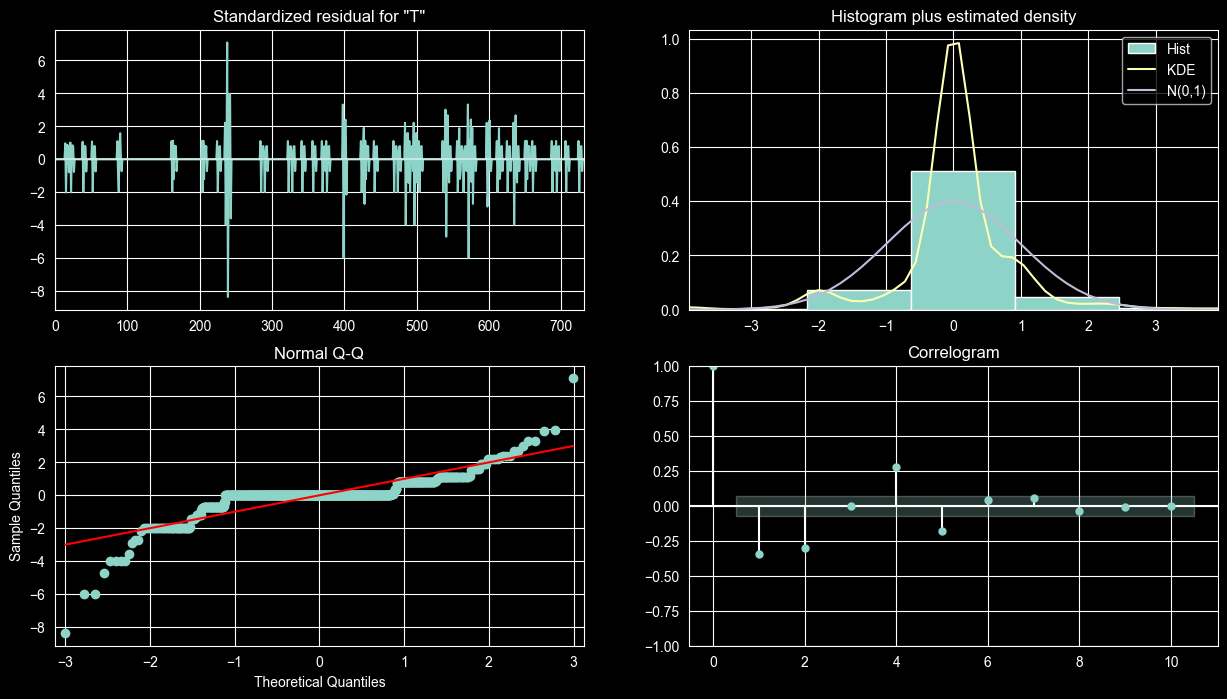

736   -0.000018
737   -0.000032
738   -0.000056
739   -0.000087
740   -0.000120
741   -0.000163
742   -0.000208
743   -0.000259
744   -0.000317
745   -0.000378
746   -0.000446
747   -0.000518
Name: predicted_mean, dtype: float64


In [66]:
# ARIMA Forcast for CyberOps_df_TS after differencing
model_arima_ts_diff = ARIMA(CyberOps_df_TS['Total Exploits_diff'].dropna(), order=(2, 4, 2))
model_arima_ts_fit_diff = model_arima_ts_diff.fit()
model_arima_ts_fit_diff.plot_diagnostics(figsize=(15,8))
plt.show()

# Forecast
n_periods = period1_M
model_arima_ts_forecast_diff = model_arima_ts_fit_diff.forecast(steps=n_periods)
print(model_arima_ts_forecast_diff)

In [67]:
# Split the data into 70% training, 30% testing
X_train = CyberOps_df_TS[:int(0.8*(len(CyberOps_df_TS)))]
X_test = CyberOps_df_TS[int(0.8*(len(CyberOps_df_TS))):]

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)

X_train shape:  (588, 2)
X_test shape:  (148, 2)


In [68]:
start = len(X_train)
end = len(X_train) + len(X_test) - 1

# Get Predictions
predictions = model_arima_ts_fit_diff.predict(start=start, end=end, typ='levels').rename('ARIMA Predictions')

# Get Confidence Intervals
confidence_intervals = model_arima_ts_fit_diff.get_forecast(n_periods).conf_int()

lower_limits = confidence_intervals.loc[:, 'lower Total Exploits_diff']
upper_limits = confidence_intervals.loc[:, 'upper Total Exploits_diff']

# Get the difference between the lower and upper confidence intervals
confidence_intervals['diff'] = confidence_intervals['upper Total Exploits_diff'] - confidence_intervals['lower Total Exploits_diff']

#print lower and upper limits
print(lower_limits)
print(upper_limits)

# Print confidence intervals
print(confidence_intervals)

736    -1.766836
737    -2.256749
738    -3.361598
739    -4.645469
740    -5.789182
741    -7.347412
742    -8.842848
743   -10.480889
744   -12.288591
745   -14.109154
746   -16.100159
747   -18.167201
Name: lower Total Exploits_diff, dtype: float64
736     1.766800
737     2.256685
738     3.361486
739     4.645295
740     5.788942
741     7.347087
742     8.842432
743    10.480370
744    12.287957
745    14.108397
746    16.099268
747    18.166165
Name: upper Total Exploits_diff, dtype: float64
     lower Total Exploits_diff  upper Total Exploits_diff       diff
736                  -1.766836                   1.766800   3.533636
737                  -2.256749                   2.256685   4.513434
738                  -3.361598                   3.361486   6.723084
739                  -4.645469                   4.645295   9.290764
740                  -5.789182                   5.788942  11.578123
741                  -7.347412                   7.347087  14.694498
742          

In [69]:
# Make Date index for predictions of 12 months
confidence_intervals['Date'] = pd.date_range(start='2023-01-01', periods=period1_M, freq='M')
confidence_intervals.set_index('Date', inplace=True)

lower_limits.index = pd.date_range(start='2023-01-01', periods=period1_M, freq='M')
upper_limits.index = pd.date_range(start='2023-01-01', periods=period1_M, freq='M')

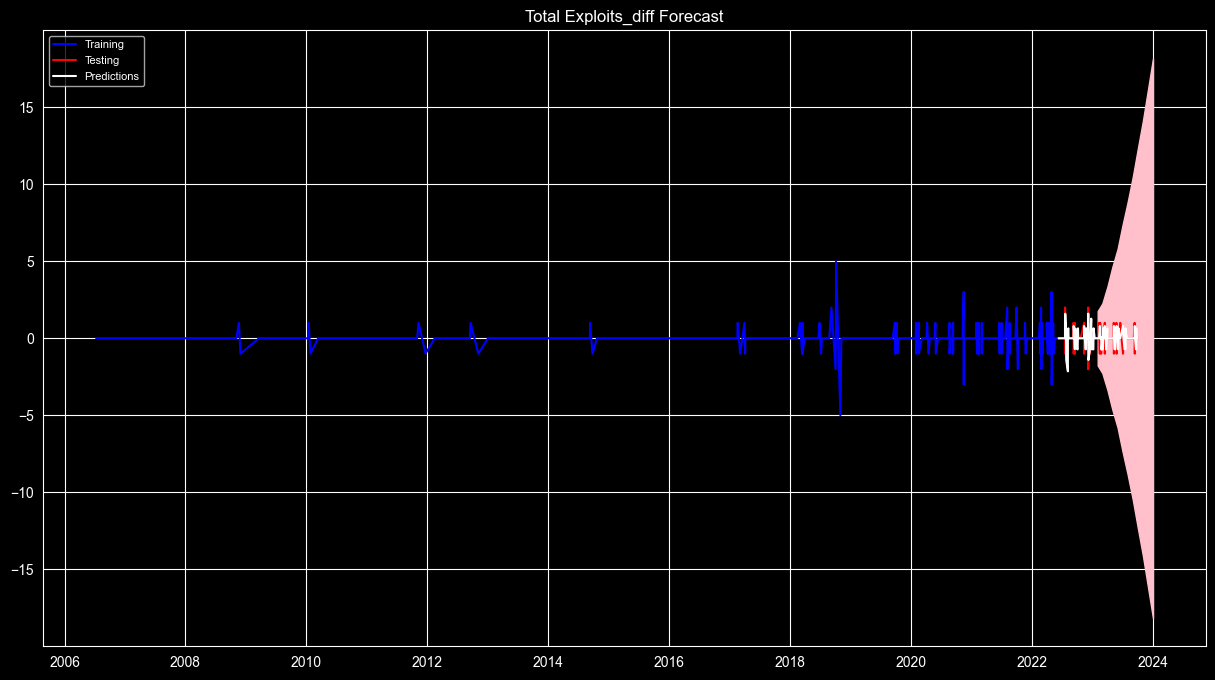

In [70]:
# Plot confidence intervals
plt.figure(figsize=(15,8))
plt.plot(X_train['Total Exploits_diff'], label='Training', color='blue')
plt.plot(X_test['Total Exploits_diff'], label='Testing', color='red')
plt.plot(predictions, label='Predictions', color='white')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink')
plt.title('Total Exploits_diff Forecast')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [71]:
predictions = predictions._append(pd.Series([0], index=['2023-09-28']))

In [72]:
# Check lengths
print("Length of X_test['Total Exploits_diff']: ", len(X_test['Total Exploits_diff']))
print("Length of predictions: ", len(predictions))

Length of X_test['Total Exploits_diff']:  148
Length of predictions:  149


In [73]:
# If predictions is longer, trim the extra data point
if len(predictions) > len(X_test['Total Exploits_diff']):
    predictions = predictions[:-1]

In [74]:
# MAE Calculation after differencing
mae_diff = mean_absolute_error(X_test['Total Exploits_diff'], predictions)
print('*** MAE of Differenced Data ***')
print('The Mean Absolute Error of our forecasts is {}'.format(round(mae_diff, 2)))
print('The Accuracy of our forecasts is {}'.format(round(100 - mae_diff, 2)))

*** MAE of Differenced Data ***
The Mean Absolute Error of our forecasts is 0.46
The Accuracy of our forecasts is 99.54


In [75]:
# MSE Calculation after differencing
mse_diff = mean_squared_error(X_test['Total Exploits_diff'], predictions)
print('*** MSE after differencing ***')
print('The Mean Squared Error of our forecasts is {}'.format(round(mse_diff, 2)))
print('The Accuracy of our forecasts is {}'.format(round(100 - mse_diff, 2)))

*** MSE after differencing ***
The Mean Squared Error of our forecasts is 0.67
The Accuracy of our forecasts is 99.33


In [76]:
# RMSE Calculation after differencing
rmse_diff = sqrt(mean_squared_error(X_test['Total Exploits_diff'], predictions))
print('*** RMSE After Differencing ***')
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse_diff, 2)))
print('The Accuracy of our forecasts is {}'.format(round(100 - rmse_diff, 2)))

*** RMSE After Differencing ***
The Root Mean Squared Error of our forecasts is 0.82
The Accuracy of our forecasts is 99.18


In [77]:
# Make a data frame of the predicitons
predictions_df = pd.DataFrame(predictions)
predictions_df.columns = ['Predictions']

# Merger the predictions with the original data
predictions_df = pd.merge(predictions_df,CyberOps_df_TS, left_index=True, right_index=True)
predictions_df = predictions_df[['Predictions', 'Total Exploits']]

# Add a column for Predictions + Total Exploits named Pred_Total_Exploits
predictions_df['Pred_Total_Exploits'] = predictions_df['Predictions'] + predictions_df['Total Exploits']

# Make predictions column an integer
predictions_df['Predictions'] = predictions_df['Predictions'].astype(int)

# Make Pred_Total_Exploits column an integer
predictions_df['Pred_Total_Exploits'] = predictions_df['Pred_Total_Exploits'].astype(int)

predictions_df

,Predictions,Total Exploits,Pred_Total_Exploits
Date,,,
2022-06-09 00:00:00,0,1,0
2022-06-09 00:00:00,0,1,0
2022-06-09 00:00:00,0,1,0
2022-06-09 00:00:00,0,1,0
2022-06-13 00:00:00,0,1,0
2022-06-14 00:00:00,0,1,0
2022-06-16 00:00:00,0,1,0
2022-06-17 00:00:00,0,1,0
2022-06-21 00:00:00,0,1,0
